# Evaluating the Career Achievements and Characteristics of Corbin Carroll: Characteristics Dimension & Peer Analysis

## Purpose
This script executes the characteristic-matching and peer-evaluation pipeline for MLB player Corbin Carroll. It computes structural similarities using Mahalanobis distance alongside outcome divergence to generate a Composite Career-Template Distance (CCTD) metric.

## Experimental Setting
* **Dataset:** FanGraphs career batting and tracking metrics dataset.
* **Target Features ($7$ variables):** `Swing%`, `Contact%`, `O-Contact%`, `Barrel%`, `OAA Avg`, `Spd`, and `maxEV`.
* **Target WAR Benchmark:** $\text{WAR} = 47.8$ (predicted via XGBoost regression modeling).
* **Filtering Criteria:** Strict standard deviation boundary filter ($\le 2 \text{ SD}$ deviation from Corbin Carroll across all tracking features simultaneously).

## Methods
1. **Data Cleaning & Standardization:** Drops missing records across required variables and applies Z-Score standardization ($\mu = 0, \sigma = 1$).
2. **Mahalanobis Distance Computation:** Calculates multi-dimensional mechanical and athletic distances using a pseudoinverse covariance matrix.
3. **Composite Career-Template Distance (CCTD):** Combines structural similarity ratio ($w_1 = 0.5$) with career output divergence ratio ($w_2 = 0.5$) into a unified metric:
   $$\text{CCTD} = \sqrt{w_1 \left(\frac{D_{\text{Mahal}}}{D_{\max}}\right)^2 + w_2 \left(\frac{|\text{WAR} - \text{WAR}_{\text{target}}|}{\Delta \text{WAR}_{\max}}\right)^2}$$
4. **Comparative Peer Rankings:** Isolates and sorts top-performing structural and outcome comparables into rank-ordered cohorts.

## Output
* Generates the multi-panel **CCTD Trade-off scatter plot** and **Top 10 Comparative Peer bar charts** used for visual analysis in the project report.

## Import the Data (From Fangraph)

In [6]:
import pandas as pd
test = pd.read_excel('file path')

test.head()

,Name,Team,playerid,WAR,BABIP,GB/FB,LD%,GB%,FB%,IFFB%,...,maxEV,EV,LA,Events,Pos,Spd,OAA,Innings,OAA Avg,mlbamid
0,Sean West,FLA,4393.0,-0.3,0.154,5.50,0.000,0.846,0.154,0.000,...,NaN,NaN,NaN,0.0,4.1,2.6,NaN,NaN,NaN,476811.0
1,John Van Benschoten,PIT,2228.0,0.1,0.083,1.40,0.077,0.538,0.385,0.000,...,NaN,NaN,NaN,0.0,3.0,2.6,NaN,NaN,NaN,429724.0
2,Darrell May,- - -,613.0,-0.2,0.154,1.25,0.182,0.455,0.364,0.250,...,NaN,NaN,NaN,0.0,3.0,1.6,NaN,NaN,NaN,118469.0
3,Sterling Hitchcock,- - -,824.0,-1.2,0.194,8.00,0.111,0.889,0.000,0.000,...,NaN,NaN,NaN,0.0,26.3,3.2,NaN,NaN,NaN,115982.0
4,Darren Dreifort,LAD,647.0,1.4,0.302,0.67,0.167,0.333,0.500,0.333,...,NaN,NaN,NaN,0.0,29.2,4.2,NaN,NaN,NaN,113554.0


## Calculate Mahalanobis Distance and CCTD

In [7]:
import numpy as np
import pandas as pd
from scipy.spatial.distance import mahalanobis
from sklearn.preprocessing import StandardScaler

# Load dataset
df = pd.read_excel(
    'file path'
)

# Define the required tracking variables
target_vars = [
    'Swing%',
    'Contact%',
    'O-Contact%',
    'Barrel%',
    'OAA Avg',
    'Spd',
    'maxEV',
]

# Ensure 'WAR' is included alongside target variables and player name
required_columns = target_vars + ['Name', 'WAR']
for col in required_columns:
  if col not in df.columns:
    raise ValueError(f"Required column '{col}' is missing from the dataset.")

# Step 1: Drop rows with missing values in any of the required variables or WAR
df_clean = df.dropna(subset=required_columns).copy()

# Step 2: Standardize the data for each variable (Mean = 0, SD = 1)
scaler = StandardScaler()
df_scaled_array = scaler.fit_transform(df_clean[target_vars])

# Create a clean dataframe for the scaled values
df_scaled = pd.DataFrame(
    df_scaled_array, columns=target_vars, index=df_clean.index
)
df_scaled['Name'] = df_clean['Name']
df_scaled['WAR'] = df_clean['WAR']

# Identify Corbin Carroll's row
carroll_mask = df_scaled['Name'] == 'Corbin Carroll'
if not carroll_mask.any():
  raise ValueError(
      "Corbin Carroll not found in dataset. Check 'Name' column."
  )

carroll_vector = df_scaled.loc[carroll_mask, target_vars].values[0]

# Step 3 & 4: Calculate absolute standardized difference and filter within 0.5 SD for EVERY variable
sd_differences = np.abs(df_scaled[target_vars] - carroll_vector)

# Keep players whose absolute deviation is <= 0.5 SD for all variables simultaneously
within_threshold = (sd_differences <= 2).all(axis=1)
df_filtered = df_clean[within_threshold].copy()
df_filtered_scaled = df_scaled[within_threshold].copy()

# Step 5: Calculate the Mahalanobis Distance for each filtered player
X_filtered = df_filtered_scaled[target_vars].values
cov_matrix = np.cov(X_filtered, rowvar=False)

# Invert the covariance matrix using pseudoinverse for numerical stability
inv_cov_matrix = np.linalg.pinv(cov_matrix)

# Re-extract Corbin Carroll's scaled vector from the filtered subset
carroll_filtered_vector = df_filtered_scaled.loc[
    df_filtered_scaled['Name'] == 'Corbin Carroll', target_vars
].values[0]

# Compute Mahalanobis distance for each player in the filtered set
mahalanobis_distances = []
for idx, row in df_filtered_scaled.iterrows():
  player_vector = row[target_vars].values
  m_dist = mahalanobis(player_vector, carroll_filtered_vector, inv_cov_matrix)
  mahalanobis_distances.append(m_dist)

df_filtered['Mahalanobis_Distance'] = mahalanobis_distances

# Step 6: Choose the top 10% of players based on the closest distance
top_10_percent_cutoff = np.percentile(df_filtered['Mahalanobis_Distance'], 100)
top_10_percent_players = df_filtered[
    df_filtered['Mahalanobis_Distance'] <= top_10_percent_cutoff
].copy()

# --- ADDED: Composite Career-Template Distance (CCTD) Calculation ---
# Predicted/Anchor WAR for Corbin Carroll specified as 47.8
carroll_predicted_war = 47.8

# Weights for structural similarity (w1) vs outcome divergence (w2)
w1, w2 = 0.5, 0.5

# Max pool denominator scaling references for normalization (using the filtered pool bounds)
max_mahal = df_filtered['Mahalanobis_Distance'].max()
war_differences = np.abs(top_10_percent_players['WAR'] - carroll_predicted_war)
max_war_diff = war_differences.max()
if max_war_diff <= 0:
    max_war_diff = 1.0

# Prevent division by zero if max_mahal is 0
max_mahal_denom = max_mahal if max_mahal > 0 else 1.0

cctd_scores = []
for idx, row in top_10_percent_players.iterrows():
  struct_ratio = row['Mahalanobis_Distance'] / max_mahal_denom
  output_ratio = abs(row['WAR'] - carroll_predicted_war) / max_war_diff
  
  # Euclidean combination of normalized components
  cctd = np.sqrt(w1 * (struct_ratio ** 2) + w2 * (output_ratio ** 2))
  cctd_scores.append(cctd)

top_10_percent_players['CCTD'] = cctd_scores

# Output the final matched group including WAR and CCTD score, sorted by CCTD (lowest = best overall match)
print(f'Original rows: {len(df)}')
print(f'Rows after 2 SD filter: {len(df_filtered)}')
print(f'Top 10% selected matches count: {len(top_10_percent_players)}')
# --- Put Corbin Carroll first, others sorted by CCTD ---
carroll_row = top_10_percent_players[top_10_percent_players['Name'] == 'Corbin Carroll']
other_rows = top_10_percent_players[top_10_percent_players['Name'] != 'Corbin Carroll']

# Sort others by CCTD
other_rows_sorted = other_rows.sort_values(by='CCTD')

# Combine: Carroll first, then sorted others
top_10_percent_players_ordered = pd.concat([carroll_row, other_rows_sorted], ignore_index=True)

# Output the final matched group including WAR and CCTD score
display(
    top_10_percent_players_ordered[
        ['Name', 'Mahalanobis_Distance', 'WAR', 'CCTD'] + target_vars
    ]
    #.sort_values(by='CCTD', kind='mergesort')
)

Original rows: 21747
Rows after 2 SD filter: 404
Top 10% selected matches count: 404


,Name,Mahalanobis_Distance,WAR,CCTD,Swing%,Contact%,O-Contact%,Barrel%,OAA Avg,Spd,maxEV
0,Corbin Carroll,0.000000,5.3,0.599841,0.449,0.788,0.689,0.081,0.008236,8.4,113.8
1,Jose Ramirez,2.828648,44.9,0.225174,0.431,0.873,0.790,0.062,0.004307,6.0,114.3
2,Jose Reyes,2.893923,43.9,0.233124,0.451,0.862,0.740,0.018,-0.000891,7.9,108.4
3,Brett Gardner,3.099878,38.5,0.275881,0.363,0.860,0.738,0.031,0.000826,7.1,110.1
4,Trea Turner,2.468961,33.3,0.281486,0.476,0.777,0.619,0.065,0.003009,7.4,113.5
...,...,...,...,...,...,...,...,...,...,...,...
399,Jacob Hannemann,7.112024,-0.2,0.876869,0.551,0.711,0.500,0.063,0.022676,5.0,106.3
400,Jordan Westburg,7.405429,0.5,0.884144,0.524,0.779,0.556,0.000,0.028777,5.6,107.6
401,Orlando Calixte,7.211504,-0.8,0.888356,0.498,0.710,0.484,0.000,-0.018484,5.5,107.9
402,Jahmai Jones,7.774188,-0.9,0.918033,0.442,0.795,0.525,0.039,-0.028249,5.5,108.6


## Filter the Player with range of WAR

In [8]:
# Assuming top_10_percent_players is already generated from your previous script
war_target_players = top_10_percent_players[
    (top_10_percent_players['WAR'] >= 18.86)
    & (top_10_percent_players['WAR'] <= 78.03)
]

print(f'Players in Coverage: {len(war_target_players)}')
display(
    war_target_players[
        ['Name', 'Mahalanobis_Distance', 'WAR', 'CCTD'] + target_vars
    ]
    .sort_values(by='WAR')
)

Players in Coverage: 63


,Name,Mahalanobis_Distance,WAR,CCTD,Swing%,Contact%,O-Contact%,Barrel%,OAA Avg,Spd,maxEV
2641,Dansby Swanson,4.617425,19.0,0.543939,0.473,0.741,0.597,0.083,0.005637,4.7,109.6
4089,Angel Pagan,3.012684,19.0,0.469938,0.428,0.884,0.788,0.015,-0.000347,6.9,110.7
3864,Ketel Marte,3.863025,19.2,0.504362,0.461,0.835,0.729,0.055,-0.000990,5.4,116.3
3797,Charlie Blackmon,3.425414,19.3,0.483425,0.479,0.831,0.718,0.060,-0.003777,5.9,112.7
2915,Austin Jackson,3.838511,19.4,0.500952,0.437,0.791,0.620,0.033,-0.000330,6.3,109.1
...,...,...,...,...,...,...,...,...,...,...,...
3031,Andrew McCutchen,4.023819,51.9,0.320251,0.428,0.788,0.631,0.079,-0.002280,5.1,111.4
3728,Mookie Betts,3.500715,54.7,0.290822,0.392,0.861,0.705,0.077,0.005524,6.2,114.7
4079,Ichiro Suzuki,3.883896,57.7,0.334598,0.474,0.889,0.785,0.006,-0.000053,6.5,106.9
3629,Chase Utley,4.128494,61.6,0.377329,0.412,0.846,0.689,0.032,-0.000852,5.8,107.7


## CCTD Trade-off Scatter Plot

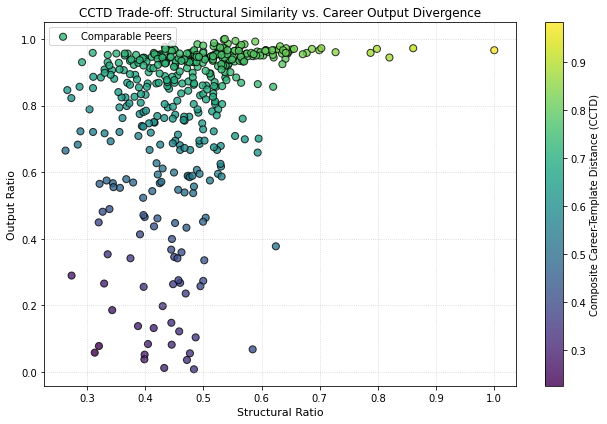

In [16]:
import matplotlib.pyplot as plt

# Prepare ratio columns for plotting
top_10_percent_players['Struct_Ratio'] = (
    top_10_percent_players['Mahalanobis_Distance'] / max_mahal_denom
)
top_10_percent_players['Output_Ratio'] = (
    np.abs(top_10_percent_players['WAR'] - carroll_predicted_war) / max_war_diff
)

plt.figure(figsize=(9, 6))


# Plot peer matches
plt.scatter(
    others_df['Struct_Ratio'],
    others_df['Output_Ratio'],
    c=others_df['CCTD'],
    cmap='viridis',
    s=50,
    alpha=0.8,
    edgecolors='k',
    label='Comparable Peers',
)


plt.colorbar(label='Composite Career-Template Distance (CCTD)')
plt.title(
    'CCTD Trade-off: Structural Similarity vs. Career Output Divergence',
    fontsize=12,
)
plt.xlabel(
    r'Structural Ratio', fontsize=11
)
plt.ylabel(
    'Output Ratio', fontsize=11
)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

## Top 10 Comparative Peer Bar Charts

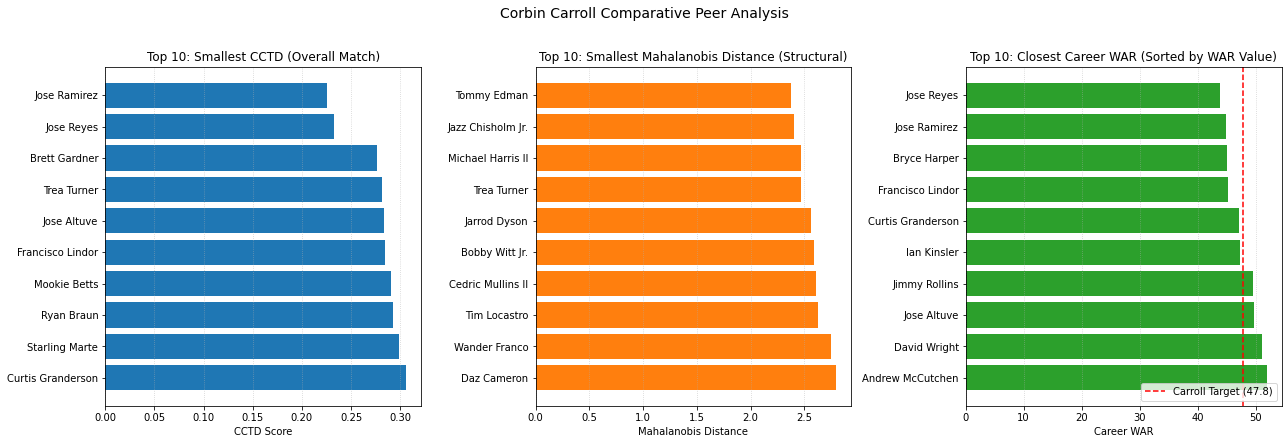

In [21]:
import matplotlib.pyplot as plt

# Ensure Corbin Carroll is excluded from the ranking comparisons to show peer players
peers_df = top_10_percent_players[top_10_percent_players['Name'] != 'Corbin Carroll'].copy()

# Calculate absolute WAR difference from Corbin Carroll's predicted 47.8 WAR
peers_df['WAR_Diff'] = np.abs(peers_df['WAR'] - carroll_predicted_war)

# Get top 10 lists for each metric
top_cctd = peers_df.sort_values(by='CCTD', ascending=True).head(10)
top_mahal = peers_df.sort_values(by='Mahalanobis_Distance', ascending=True).head(10)

# --- Updated for Chart 3: Closest WAR sorted in ascending order by WAR value ---
top_war = peers_df.sort_values(by='WAR_Diff', ascending=True).head(10).sort_values(by='WAR', ascending=False)

# Create a 1-row, 3-column subplot figure
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=False)

# --- Chart 1: Smallest CCTD ---
axes[0].barh(top_cctd['Name'][::-1], top_cctd['CCTD'][::-1], color='tab:blue')
axes[0].set_title('Top 10: Smallest CCTD (Overall Match)')
axes[0].set_xlabel('CCTD Score')
axes[0].grid(axis='x', linestyle=':', alpha=0.6)

# --- Chart 2: Smallest Mahalanobis Distance ---
axes[1].barh(top_mahal['Name'][::-1], top_mahal['Mahalanobis_Distance'][::-1], color='tab:orange')
axes[1].set_title('Top 10: Smallest Mahalanobis Distance (Structural)')
axes[1].set_xlabel('Mahalanobis Distance')
axes[1].grid(axis='x', linestyle=':', alpha=0.6)

# --- Chart 3: Closest WAR sorted ascending by WAR value ---
axes[2].barh(top_war['Name'], top_war['WAR'], color='tab:green')
axes[2].axvline(carroll_predicted_war, color='red', linestyle='--', label=f'Carroll Target ({carroll_predicted_war})')
axes[2].set_title('Top 10: Closest Career WAR (Sorted by WAR Value)')
axes[2].set_xlabel('Career WAR')
axes[2].grid(axis='x', linestyle=':', alpha=0.6)
axes[2].legend(loc='lower right')

plt.suptitle("Corbin Carroll Comparative Peer Analysis", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()